# 01: Dataset Protocol, Schema Integrity & Demographic Forensics

## 1. Research Scope & Objectives
This notebook conducts an exhaustive audit of the ASVspoof 2019 Logical Access (LA) corpus across all partitions (Train, Development, Evaluation). We evaluate dataset balance, speaker demographics, disjoint partition integrity, and spoofing attack taxonomies.

### Mathematical Formulation
Class prior distribution:
$$P(\text{bonafide}) = \frac{N_{\text{bonafide}}}{N_{\text{total}}}, \quad P(\text{spoof}) = \frac{N_{\text{spoof}}}{N_{\text{total}}}$$
Imbalance factor:
$$\rho_{\text{imbalance}} = \frac{N_{\text{spoof}}}{N_{\text{bonafide}}}$$
Speaker disjointness condition:
$$\mathcal{S}_{\text{train}} \cap \mathcal{S}_{\text{dev}} = \emptyset, \quad \mathcal{S}_{\text{train}} \cap \mathcal{S}_{\text{eval}} = \emptyset, \quad \mathcal{S}_{\text{dev}} \cap \mathcal{S}_{\text{eval}} = \emptyset$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.data.protocol_parser import ProtocolParser
from src.utils.config import path_config

sns.set_theme(style="whitegrid", palette="deep")
parser = ProtocolParser()
manifest_df = parser.load_or_generate_manifest()

In [2]:
manifest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121461 entries, 0 to 121460
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   speaker_id      121461 non-null  object
 1   audio_id        121461 non-null  object
 2   environment_id  121461 non-null  object
 3   attack_id       121461 non-null  object
 4   key             121461 non-null  object
 5   is_spoof        121461 non-null  int64 
 6   split           121461 non-null  object
 7   file_path       121461 non-null  object
 8   file_exists     121461 non-null  bool  
dtypes: bool(1), int64(1), object(7)
memory usage: 7.5+ MB


In [3]:
manifest_df.head(10)

,speaker_id,audio_id,environment_id,attack_id,key,is_spoof,split,file_path,file_exists
0,LA_0079,LA_T_1138215,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
1,LA_0079,LA_T_1271820,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
2,LA_0079,LA_T_1272637,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
3,LA_0079,LA_T_1276960,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
4,LA_0079,LA_T_1341447,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
5,LA_0079,LA_T_1363611,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
6,LA_0079,LA_T_1596451,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
7,LA_0079,LA_T_1608170,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
8,LA_0079,LA_T_1684951,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True
9,LA_0079,LA_T_1699801,-,-,bonafide,0,train,i:\ML Projects\voice-deepfake-defense-system\d...,True


## 2. Partition & Target Class Distribution Analysis
We measure the absolute volume and relative proportions of bonafide vs spoof utterances across splits.

In [4]:
split_summary = manifest_df.groupby(["split", "key"]).agg(
    utterances=("audio_id", "count"),
    unique_speakers=("speaker_id", "nunique")
).reset_index()

pivot_counts = manifest_df.groupby(["split", "key"]).size().unstack(fill_value=0)
pivot_counts["total"] = pivot_counts.sum(axis=1)
pivot_counts["bonafide_pct"] = (pivot_counts["bonafide"] / pivot_counts["total"]) * 100
pivot_counts["spoof_pct"] = (pivot_counts["spoof"] / pivot_counts["total"]) * 100
pivot_counts["imbalance_ratio"] = pivot_counts["spoof"] / pivot_counts["bonafide"]
pivot_counts

key,bonafide,spoof,total,bonafide_pct,spoof_pct,imbalance_ratio
split,,,,,,
dev,2548,22296,24844,10.255997,89.744003,8.750392
eval,7355,63882,71237,10.324691,89.675309,8.685520
train,2580,22800,25380,10.165485,89.834515,8.837209


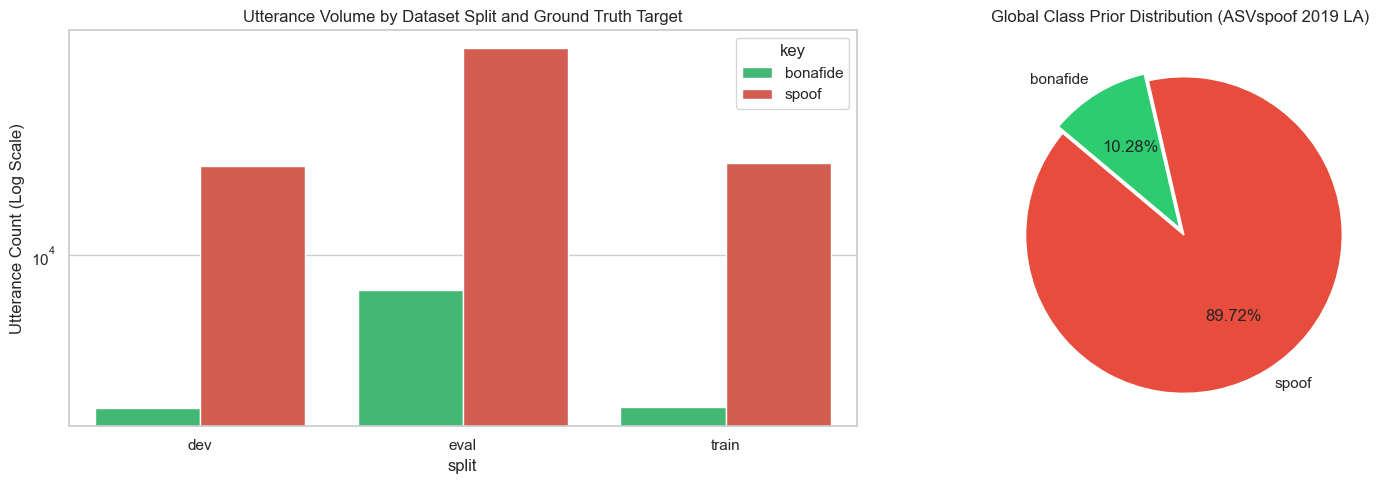

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=split_summary, x="split", y="utterances", hue="key", palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Utterance Volume by Dataset Split and Ground Truth Target")
axes[0].set_yscale("log")
axes[0].set_ylabel("Utterance Count (Log Scale)")

pie_data = manifest_df["key"].value_counts()
axes[1].pie(pie_data, labels=pie_data.index, autopct="%1.2f%%", colors=["#e74c3c", "#2ecc71"], startangle=140, explode=(0.05, 0))
axes[1].set_title("Global Class Prior Distribution (ASVspoof 2019 LA)")
plt.tight_layout()
plt.show()

## 3. Attack Algorithm Taxonomy & Generation Forensics
The ASVspoof 2019 corpus encompasses 19 distinct speech synthesis (TTS) and voice conversion (VC) systems.

In [6]:
spoof_df = manifest_df[manifest_df.key == "spoof"].copy()
attack_summary = spoof_df.groupby(["split", "attack_id"]).size().unstack(fill_value=0)
attack_summary

attack_id,A01,A02,A03,A04,A05,A06,A07,A08,A09,A10,A11,A12,A13,A14,A15,A16,A17,A18,A19
split,,,,,,,,,,,,,,,,,,,
dev,3716,3716,3716,3716,3716,3716,0,0,0,0,0,0,0,0,0,0,0,0,0
eval,0,0,0,0,0,0,4914,4914,4914,4914,4914,4914,4914,4914,4914,4914,4914,4914,4914
train,3800,3800,3800,3800,3800,3800,0,0,0,0,0,0,0,0,0,0,0,0,0


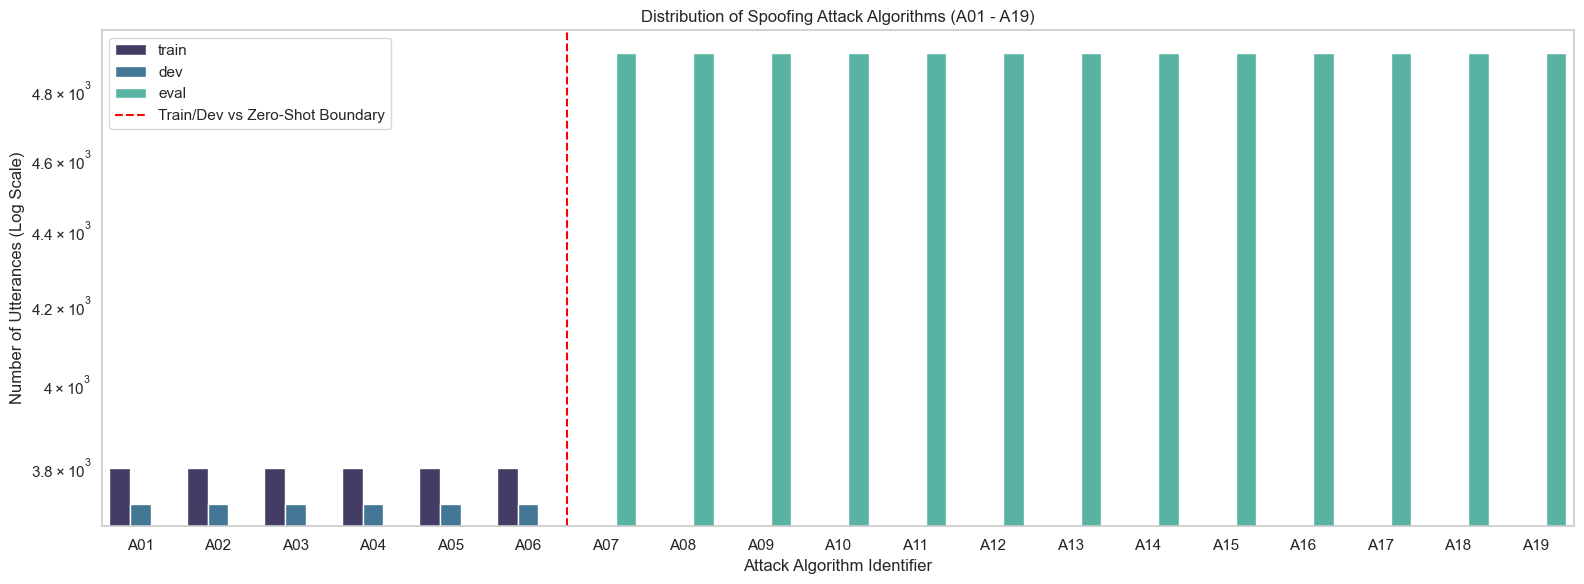

In [7]:
plt.figure(figsize=(16, 6))
order = sorted(spoof_df["attack_id"].unique())
sns.countplot(data=spoof_df, x="attack_id", hue="split", order=order, palette="mako")
plt.title("Distribution of Spoofing Attack Algorithms (A01 - A19)")
plt.xlabel("Attack Algorithm Identifier")
plt.ylabel("Number of Utterances (Log Scale)")
plt.yscale("log")
plt.axvline(x=5.5, color="red", linestyle="--", label="Train/Dev vs Zero-Shot Boundary")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Speaker Demographic & Disjoint Partition Verification
Ensuring zero speaker leakage between partitions is crucial for unbiased generalization assessment.

In [8]:
train_spk = set(manifest_df[manifest_df.split == "train"]["speaker_id"].unique())
dev_spk = set(manifest_df[manifest_df.split == "dev"]["speaker_id"].unique())
eval_spk = set(manifest_df[manifest_df.split == "eval"]["speaker_id"].unique())

print(f"Train unique speakers: {len(train_spk)}")
print(f"Dev unique speakers: {len(dev_spk)}")
print(f"Eval unique speakers: {len(eval_spk)}")
print(f"Total unique speakers: {len(train_spk | dev_spk | eval_spk)}")
print(f"Train & Dev Intersection: {train_spk & dev_spk}")
print(f"Train & Eval Intersection: {train_spk & eval_spk}")
print(f"Dev & Eval Intersection: {dev_spk & eval_spk}")

Train unique speakers: 20
Dev unique speakers: 20
Eval unique speakers: 67
Total unique speakers: 107
Train & Dev Intersection: set()
Train & Eval Intersection: set()
Dev & Eval Intersection: set()


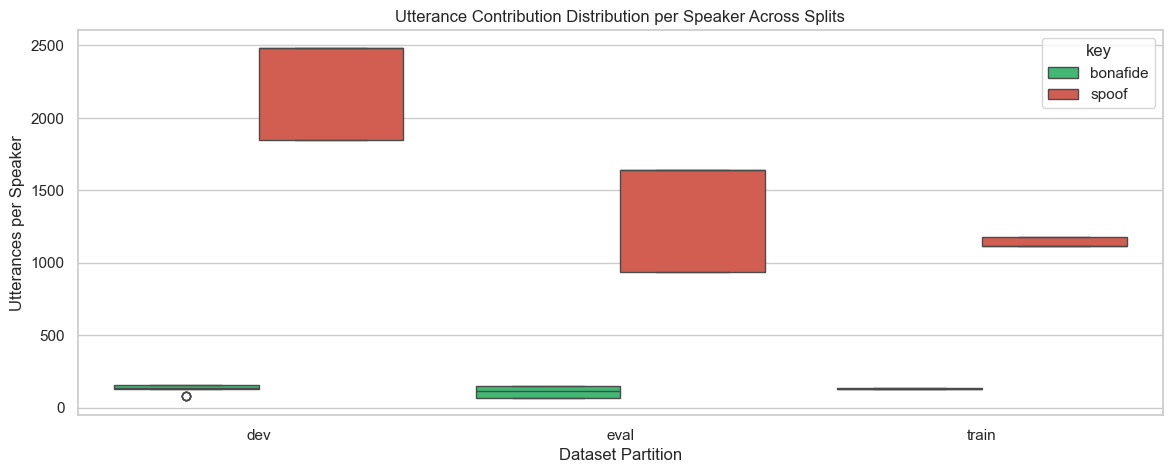

In [9]:
spk_utterances = manifest_df.groupby(["split", "speaker_id", "key"]).size().reset_index(name="count")
plt.figure(figsize=(14, 5))
sns.boxplot(data=spk_utterances, x="split", y="count", hue="key", palette=["#2ecc71", "#e74c3c"])
plt.title("Utterance Contribution Distribution per Speaker Across Splits")
plt.xlabel("Dataset Partition")
plt.ylabel("Utterances per Speaker")
plt.show()

## 5. File Integrity & Existence Audit
We verify that every single referenced audio file exists on disk.

In [10]:
missing = manifest_df[~manifest_df["file_exists"]]
print(f"Total missing audio files: {len(missing)}")
print(f"Verified files present on disk: {len(manifest_df[manifest_df.file_exists]):,}")

Total missing audio files: 0
Verified files present on disk: 121,461
